# GenMol de novo molecule generation (hosted NVIDIA API)

This notebook:
- Generates **20 novel, drug-like molecules** using **GenMol** in **pure de novo** mode (no scaffold).
- Uses the **hosted NVIDIA API** (`NGC_API_KEY` must be set in the environment).
- Requests extra molecules to compensate for invalid/duplicate filtering.
- Ranks results by **QED** (drug-likeness) and visualizes structures with **RDKit**.

> Note: GenMol expects **SAFE notation** in the `smiles` field. For de novo generation we use a mask like `[*{20-30}]`.

In [1]:
# --- Environment & dependencies ---
import os
import sys
import importlib


def _ensure_pkg(import_name: str, pip_name: str | None = None):
    """Import a package; if missing, install it via pip then import."""
    try:
        return importlib.import_module(import_name)
    except Exception:
        pkg = pip_name or import_name
        print(f"Installing missing dependency: {pkg}")
        # Use pip inside notebook kernel
        import subprocess

        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        return importlib.import_module(import_name)


requests = _ensure_pkg("requests")
pd = _ensure_pkg("pandas")
_ensure_pkg("tqdm")

# RDKit: prefer conda-forge, but in many notebook envs `rdkit-pypi` works.
try:
    from rdkit import Chem
    from rdkit.Chem import QED, Descriptors, Draw
except Exception:
    _ensure_pkg("rdkit", pip_name="rdkit-pypi")
    from rdkit import Chem
    from rdkit.Chem import QED, Descriptors, Draw

# Optional: nicer rendering in notebooks
try:
    from rdkit.Chem.Draw import IPythonConsole  # noqa: F401
except Exception:
    pass

# Confirm API key is present (do not print it)
assert os.environ.get("NGC_API_KEY"), "NGC_API_KEY is not set in the environment"

print("Ready.")

Ready.


## 1) De novo generation request (GenMol hosted API)

We use a **SAFE mask** as the input pattern:

- `[*{20-30}]` asks GenMol to generate molecules with roughly 20–30 tokens worth of structure.

We request **more than 20** molecules with `unique=True` because the service may filter invalid/duplicate candidates.

In [3]:
from __future__ import annotations

from typing import Any

import pandas as pd
import requests

HOSTED_URL = "https://health.api.nvidia.com/v1/biology/nvidia/genmol/generate"


def genmol_denovo_qed(
    num_molecules: int = 80,
    safe_input: str = "[*{20-30}]",
    temperature: str = "1.0",
    noise: str = "1.0",
    step_size: int = 1,
    unique: bool = True,
    timeout_s: int = 180,
) -> dict[str, Any]:
    """Call hosted GenMol for *de novo* generation with QED scoring."""
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {os.environ['NGC_API_KEY']}",
    }
    payload = {
        "smiles": safe_input,  # SAFE notation (not plain SMILES)
        "num_molecules": int(num_molecules),
        "temperature": str(temperature),  # must be string
        "noise": str(noise),              # must be string
        "step_size": int(step_size),
        "scoring": "QED",
        "unique": bool(unique),
    }

    resp = requests.post(HOSTED_URL, headers=headers, json=payload, timeout=timeout_s)
    resp.raise_for_status()
    out = resp.json()
    if out.get("status") != "success":
        raise RuntimeError(out.get("error", f"GenMol failed: {out}"))
    return out


# --- Make the API call ---
# If your environment cannot reach NVIDIA endpoints (e.g., DNS / outbound network blocked),
# this cell will warn and leave `df_raw` empty. Re-run in a network-enabled environment.
result: dict[str, Any] | None = None
try:
    result = genmol_denovo_qed(num_molecules=120, safe_input="[*{20-30}]", unique=True)
    mols = result.get("molecules", [])
    print(f"GenMol returned {len(mols)} candidates")
except requests.exceptions.RequestException as e:
    print("WARNING: Could not reach hosted GenMol API.\n"
          "Reason:", repr(e), "\n\n"
          "If you are running in a restricted environment, re-run this notebook where outbound HTTPS to\n"
          "https://health.api.nvidia.com is allowed.")
    mols = []

# Tabulate raw outputs
rows = [{"smiles": m.get("smiles"), "genmol_qed": m.get("score")} for m in mols]
df_raw = pd.DataFrame(rows).dropna().drop_duplicates(subset=["smiles"]).sort_values("genmol_qed", ascending=False)
df_raw.head(10)

GenMol returned 120 candidates


                                              smiles  genmol_qed
0            C[C@H]1CN(C)CCN1C(=O)Nc1ccccc1Oc1ccccc1       0.937
1                       O=C(O)Cc1ccccc1-c1ccc(Br)cc1       0.935
2              C[C@@H](Nc1ccc(N2CCCC2=O)cc1)c1ccncc1       0.934
3                     Cc1ccccc1C(=O)NC1CC(c2nccs2)C1       0.932
4            Cn1nnc2cc(CNC(=O)[C@@]3(C)CC3(C)C)ccc21       0.930
5                      Brc1ccc(C2CNCCN2Cc2ccccc2)cc1       0.925
6                   CN1CCC(NCc2ccc(-c3ccccc3)cc2)CC1       0.921
7                      N#Cc1ccccc1CNC(=O)C1(F)CCCCC1       0.908
8                CCc1ccc(NC(=O)NC2CCN(c3cccs3)C2)cc1       0.903
9  c1cc2ccc([C@@H]3CCC[C@@H]([NH2+][C@@H]4CCCOC4)...       0.899

## 2) Clean up, enforce uniqueness, and select top-20 by QED

GenMol returns a `score` field for each molecule when `scoring="QED"`.

Below we:
- Canonicalize SMILES with RDKit
- Drop invalid molecules
- Enforce uniqueness by canonical SMILES
- Select the **top 20** by QED

In [4]:
from rdkit import Chem
from rdkit.Chem import QED


def canonicalize_smiles(smiles: str) -> str | None:
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    return Chem.MolToSmiles(m, canonical=True)


def compute_qed(smiles: str) -> float | None:
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    return float(QED.qed(m))


if df_raw.empty:
    raise RuntimeError("No molecules available. Re-run the API call cell after network access is enabled.")

# Canonicalize + validate
_df = df_raw.copy()
_df["canon_smiles"] = _df["smiles"].map(canonicalize_smiles)
_df = _df.dropna(subset=["canon_smiles"]).drop_duplicates(subset=["canon_smiles"]).copy()

# Recompute QED with RDKit for verification / consistent ranking
_df["rdkit_qed"] = _df["canon_smiles"].map(compute_qed)
_df = _df.dropna(subset=["rdkit_qed"]).sort_values(["rdkit_qed"], ascending=False)

# Select top-20
TOP_N = 20

df_top20 = _df.head(TOP_N).reset_index(drop=True)
print(f"Valid unique molecules available: {len(_df)}")
print(f"Selected top {len(df_top20)} molecules")

df_top20[["canon_smiles", "genmol_qed", "rdkit_qed"]].head(20)

Valid unique molecules available: 120
Selected top 20 molecules


                                         canon_smiles  genmol_qed  rdkit_qed
0             C[C@H]1CN(C)CCN1C(=O)Nc1ccccc1Oc1ccccc1       0.937   0.936756
1                        O=C(O)Cc1ccccc1-c1ccc(Br)cc1       0.935   0.934892
2               C[C@@H](Nc1ccc(N2CCCC2=O)cc1)c1ccncc1       0.934   0.934079
3                      Cc1ccccc1C(=O)NC1CC(c2nccs2)C1       0.932   0.932407
4             Cn1nnc2cc(CNC(=O)[C@@]3(C)CC3(C)C)ccc21       0.930   0.929593
5                       Brc1ccc(C2CNCCN2Cc2ccccc2)cc1       0.925   0.924558
6                    CN1CCC(NCc2ccc(-c3ccccc3)cc2)CC1       0.921   0.921313
7                       N#Cc1ccccc1CNC(=O)C1(F)CCCCC1       0.908   0.908134
8                 CCc1ccc(NC(=O)NC2CCN(c3cccs3)C2)cc1       0.903   0.903117
9   c1cc2ccc([C@@H]3CCC[C@@H]([NH2+][C@@H]4CCCOC4)...       0.899   0.898758
10                       Brc1ccc(C2CCCNC2)cc1OC1CCCC1       0.898   0.897941
11    Cc1nc(C2CC2)ccc1C(=O)NC[C@H]1C[C@H](c2ccccc2)C1       0.897   0.897250

## 3) Save results + visualize top-20 with RDKit

We save a TSV/SMI and render a grid image of the top molecules.

Wrote:
 - outputs/genmol_denovo_top20_qed.tsv
 - outputs/genmol_denovo_top20_qed.smi


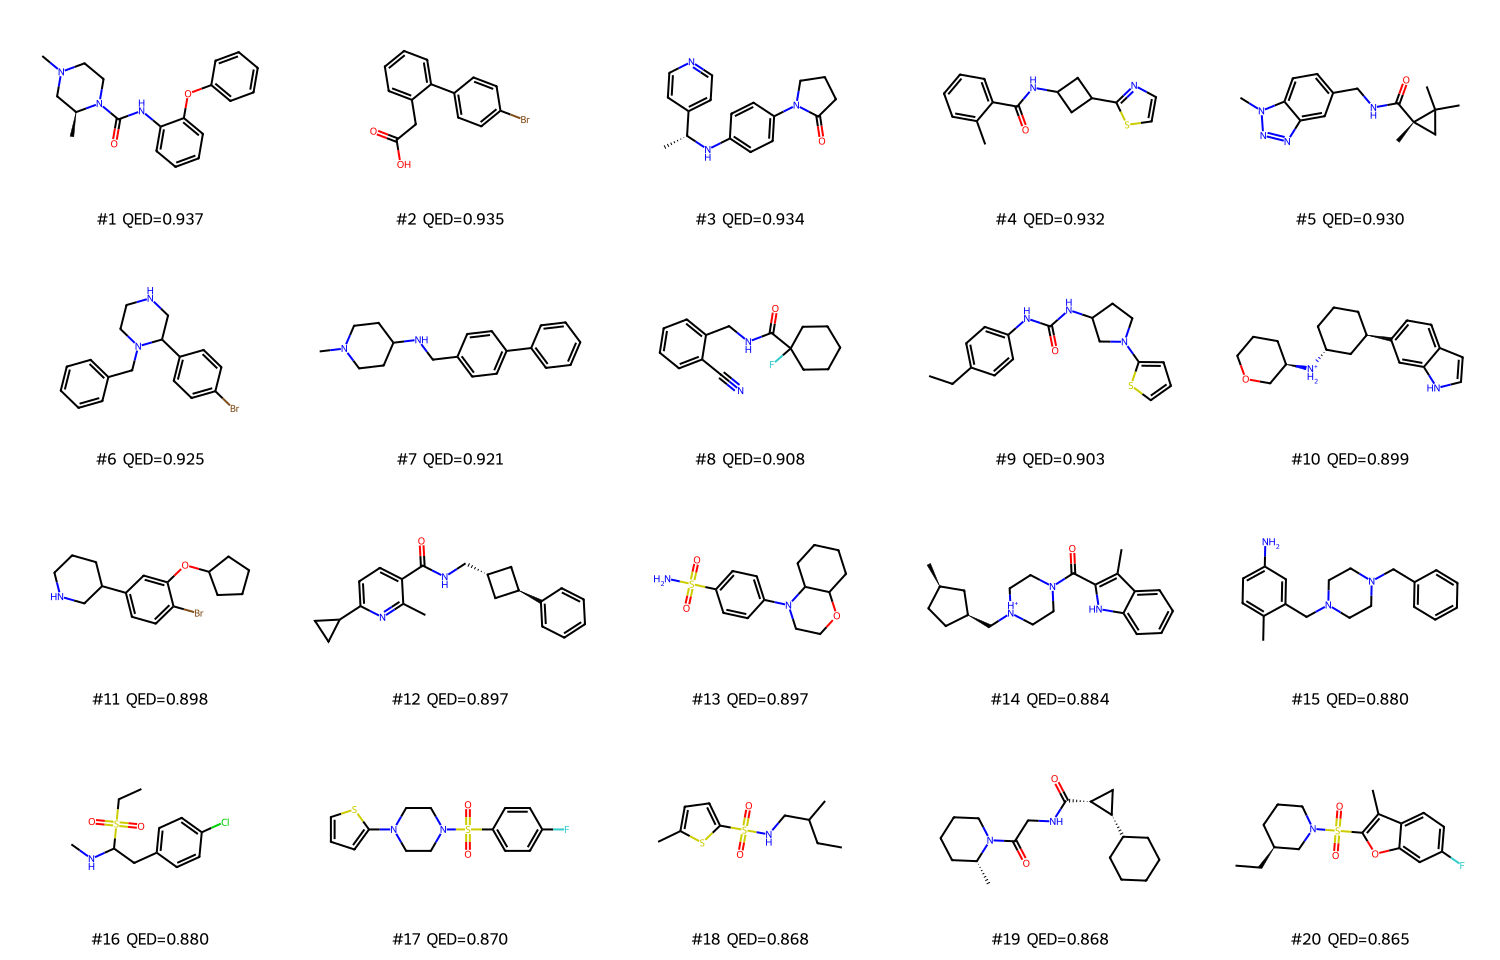

In [5]:
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import Draw

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True, parents=True)

# Save as TSV
out_tsv = OUTDIR / "genmol_denovo_top20_qed.tsv"
df_top20.to_csv(out_tsv, sep="\t", index=False)

# Save as .smi (SMILES + score)
out_smi = OUTDIR / "genmol_denovo_top20_qed.smi"
with out_smi.open("w", encoding="utf-8") as f:
    f.write("smiles\trdkit_qed\n")
    for _, r in df_top20.iterrows():
        f.write(f"{r['canon_smiles']}\t{r['rdkit_qed']:.4f}\n")

print("Wrote:")
print(" -", out_tsv)
print(" -", out_smi)

# Visualize
mols = [Chem.MolFromSmiles(s) for s in df_top20["canon_smiles"].tolist()]
legends = [f"#{i+1} QED={q:.3f}" for i, q in enumerate(df_top20["rdkit_qed"].tolist())]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(300, 240),
    legends=legends,
    useSVG=False,
)
img